In [ ]:
# ============================================
# EXPERIMENT 10: Bayesian Hypothesis Testing
# ============================================

# Install required library (Run once in Colab)
!pip install scipy matplotlib seaborn --quiet

In [ ]:
# ============================================
# STEP 1: Import Libraries
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, beta

np.random.seed(42)

In [ ]:
# ============================================
# STEP 2: Generate Simulated Dataset
# Given:
# Mean = 52, SD = 10, n = 30
# ============================================

mu_true = 52
sigma = 10
n = 30

data = np.random.normal(mu_true, sigma, n)

sample_mean = np.mean(data)

print("Generated Data:\n", data)
print("\nSample Mean =", round(sample_mean, 3))

Generated Data:
 [56.96714153 50.61735699 58.47688538 67.23029856 49.65846625 49.65863043
 67.79212816 59.67434729 47.30525614 57.42560044 47.36582307 47.34270246
 54.41962272 32.86719755 34.75082167 46.37712471 41.8716888  55.14247333
 42.91975924 37.87696299 66.65648769 49.742237   52.67528205 37.75251814
 46.55617275 53.1092259  40.49006423 55.75698018 45.9936131  49.0830625 ]

Sample Mean = 50.119


In [ ]:
# ============================================
# STEP 3: Define Prior Distribution
# Prior belief: mu ~ Normal(50, 10^2)
# ============================================

prior_mean = 50
prior_sd = 10
prior_var = prior_sd**2

In [ ]:
# ============================================
# STEP 4: Compute Posterior Distribution
# Formula for Normal-Normal Conjugate Posterior
# ============================================

posterior_var = 1 / ((1/prior_var) + (n/sigma**2))
posterior_mean = posterior_var * (
    (prior_mean/prior_var) + (n*sample_mean/sigma**2)
)

posterior_sd = np.sqrt(posterior_var)

print("Posterior Mean =", round(posterior_mean, 3))
print("Posterior SD =", round(posterior_sd, 3))

Posterior Mean = 50.115
Posterior SD = 1.796


In [ ]:
# ============================================
# STEP 5: Calculate 95% Credible Interval
# ============================================

credible_lower = posterior_mean - 1.96 * posterior_sd
credible_upper = posterior_mean + 1.96 * posterior_sd

print("95% Credible Interval:")
print(f"({credible_lower:.3f}, {credible_upper:.3f})")

95% Credible Interval:
(46.594, 53.635)


In [ ]:
# ============================================
# STEP 6: Compute Bayes Factor Approximation
# H0: mu = 50
# H1: mu ≠ 50
# ============================================

mu0 = 50

likelihood_h0 = norm.pdf(sample_mean, loc=mu0, scale=sigma/np.sqrt(n))
likelihood_h1 = norm.pdf(sample_mean, loc=posterior_mean, scale=sigma/np.sqrt(n))

BF10 = likelihood_h1 / likelihood_h0

print("Bayes Factor BF10 =", round(BF10, 4))

if BF10 > 1:
    print("Evidence supports Alternative Hypothesis (H1)")
else:
    print("Evidence supports Null Hypothesis (H0)")

Bayes Factor BF10 = 1.0021
Evidence supports Alternative Hypothesis (H1)


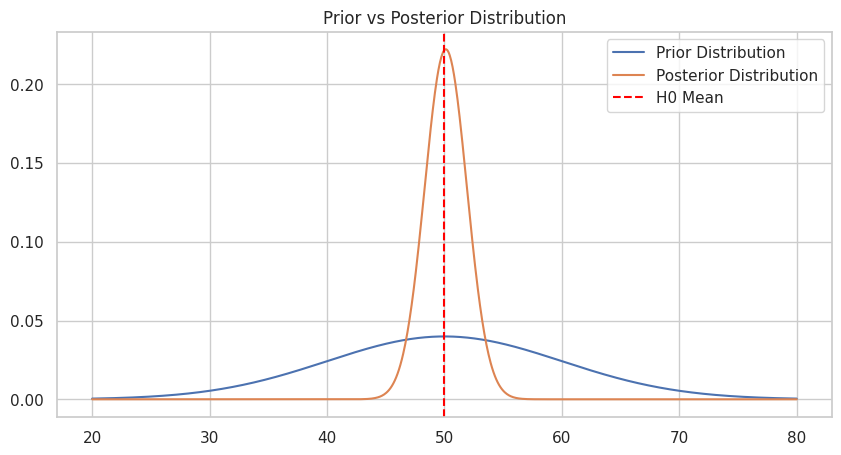

In [ ]:
# ============================================
# STEP 7: Plot Prior and Posterior
# ============================================

x = np.linspace(20, 80, 1000)

prior_pdf = norm.pdf(x, prior_mean, prior_sd)
posterior_pdf = norm.pdf(x, posterior_mean, posterior_sd)

plt.figure(figsize=(10,5))
plt.plot(x, prior_pdf, label='Prior Distribution')
plt.plot(x, posterior_pdf, label='Posterior Distribution')
plt.axvline(mu0, color='red', linestyle='--', label='H0 Mean')
plt.title("Prior vs Posterior Distribution")
plt.legend()
plt.show()

In [ ]:
# ============================================
# STEP 8: Bayesian A/B Testing (Beta-Binomial)
# A: 40/200
# B: 55/200
# ============================================

success_A = 40
trials_A = 200

success_B = 55
trials_B = 200

# Uniform Prior Beta(1,1)
alpha_prior = 1
beta_prior = 1

# Posterior for A
alpha_A = alpha_prior + success_A
beta_A = beta_prior + (trials_A - success_A)

# Posterior for B
alpha_B = alpha_prior + success_B
beta_B = beta_prior + (trials_B - success_B)

print("Posterior A ~ Beta({}, {})".format(alpha_A, beta_A))
print("Posterior B ~ Beta({}, {})".format(alpha_B, beta_B))

Posterior A ~ Beta(41, 161)
Posterior B ~ Beta(56, 146)


In [ ]:
# ============================================
# STEP 9: Estimate Probability P(B > A)
# Monte Carlo Simulation
# ============================================

samples = 100000

posterior_samples_A = np.random.beta(alpha_A, beta_A, samples)
posterior_samples_B = np.random.beta(alpha_B, beta_B, samples)

prob_B_better = np.mean(posterior_samples_B > posterior_samples_A)

print("P(B > A) =", round(prob_B_better, 4))

P(B > A) = 0.9586


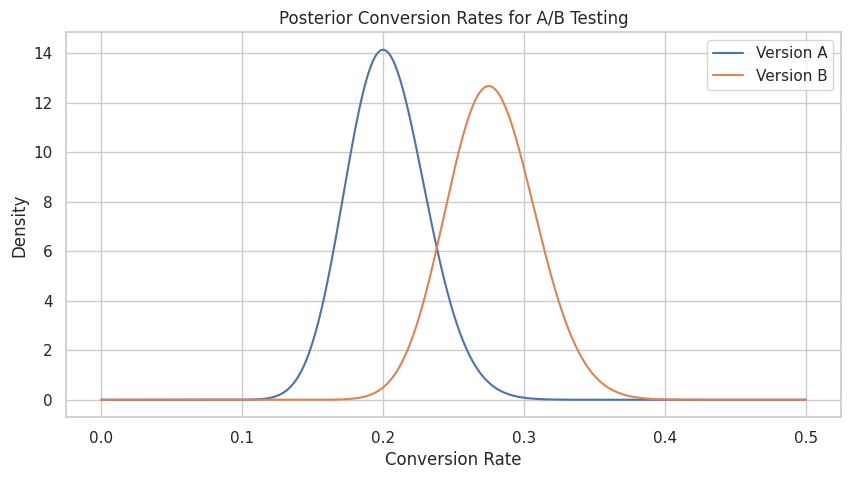

In [ ]:
# ============================================
# STEP 10: Plot A/B Posterior Distributions
# ============================================

x = np.linspace(0, 0.5, 1000)

plt.figure(figsize=(10,5))
plt.plot(x, beta.pdf(x, alpha_A, beta_A), label='Version A')
plt.plot(x, beta.pdf(x, alpha_B, beta_B), label='Version B')

plt.title("Posterior Conversion Rates for A/B Testing")
plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
# ============================================
# STEP 11: Final Interpretation
# ============================================

print("\n===== INTERPRETATION =====")

print(f"Bayes Factor BF10 = {BF10:.3f}")
print(f"Posterior Mean = {posterior_mean:.3f}")
print(f"95% Credible Interval = ({credible_lower:.3f}, {credible_upper:.3f})")
print(f"P(B > A) = {prob_B_better:.3f}")

if prob_B_better > 0.95:
    print("Version B is significantly better than Version A.")
else:
    print("Insufficient Bayesian evidence that B is better than A.")


===== INTERPRETATION =====
Bayes Factor BF10 = 1.002
Posterior Mean = 50.115
95% Credible Interval = (46.594, 53.635)
P(B > A) = 0.959
Version B is significantly better than Version A.


Extras

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, beta

sns.set(style="whitegrid")
np.random.seed(42)

In [ ]:
mu_true = 52
sigma = 10
n = 30

data = np.random.normal(mu_true, sigma, n)

sample_mean = np.mean(data)

print("Sample Mean:", round(sample_mean, 3))

Sample Mean: 50.119


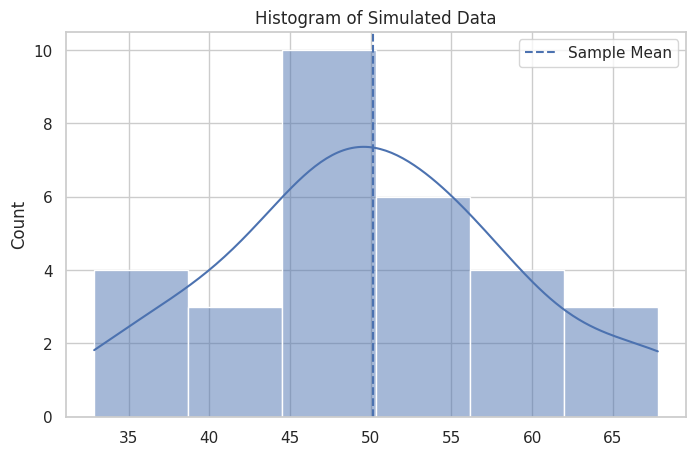

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data, kde=True)
plt.axvline(sample_mean, linestyle='--', label='Sample Mean')
plt.title("Histogram of Simulated Data")
plt.legend()
plt.show()

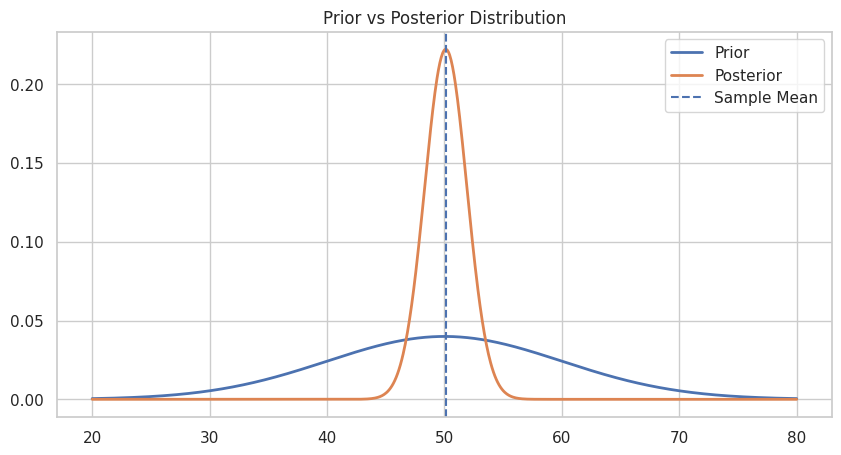

In [ ]:
# Prior
prior_mean = 50
prior_sd = 10
prior_var = prior_sd**2

# Posterior
posterior_var = 1 / ((1/prior_var) + (n/sigma**2))
posterior_mean = posterior_var * ((prior_mean/prior_var) + (n*sample_mean/sigma**2))
posterior_sd = np.sqrt(posterior_var)

x = np.linspace(20, 80, 1000)

plt.figure(figsize=(10,5))
plt.plot(x, norm.pdf(x, prior_mean, prior_sd), label="Prior", linewidth=2)
plt.plot(x, norm.pdf(x, posterior_mean, posterior_sd), label="Posterior", linewidth=2)

plt.axvline(sample_mean, linestyle='--', label='Sample Mean')
plt.title("Prior vs Posterior Distribution")
plt.legend()
plt.show()

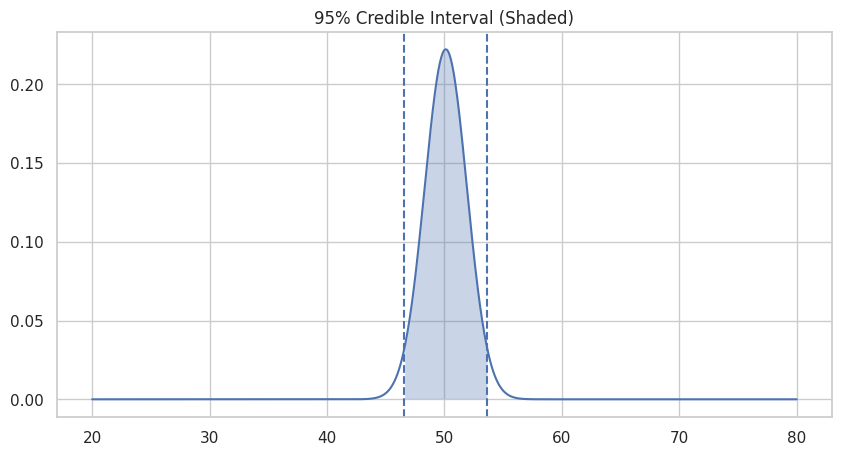

95% CI: (46.59, 53.63)


In [ ]:
lower = posterior_mean - 1.96 * posterior_sd
upper = posterior_mean + 1.96 * posterior_sd

x_fill = np.linspace(lower, upper, 500)

plt.figure(figsize=(10,5))
plt.plot(x, norm.pdf(x, posterior_mean, posterior_sd))
plt.fill_between(x_fill,
                 norm.pdf(x_fill, posterior_mean, posterior_sd),
                 alpha=0.3)

plt.axvline(lower, linestyle='--')
plt.axvline(upper, linestyle='--')

plt.title("95% Credible Interval (Shaded)")
plt.show()

print(f"95% CI: ({lower:.2f}, {upper:.2f})")

In [ ]:
mu0 = 50

likelihood_h0 = norm.pdf(sample_mean, mu0, sigma/np.sqrt(n))
likelihood_h1 = norm.pdf(sample_mean, posterior_mean, sigma/np.sqrt(n))

BF10 = likelihood_h1 / likelihood_h0

print("Bayes Factor:", round(BF10, 3))

Bayes Factor: 1.002


In [ ]:
def interpret_bf(bf):
    if bf < 1:
        return "Supports H0"
    elif bf < 3:
        return "Weak evidence"
    elif bf < 10:
        return "Moderate evidence"
    elif bf < 30:
        return "Strong evidence"
    else:
        return "Very strong evidence"

print("Interpretation:", interpret_bf(BF10))

Interpretation: Weak evidence


In [ ]:
# Data
success_A, trials_A = 40, 200
success_B, trials_B = 55, 200

# Posterior
alpha_A, beta_A = 1 + success_A, 1 + (trials_A - success_A)
alpha_B, beta_B = 1 + success_B, 1 + (trials_B - success_B)

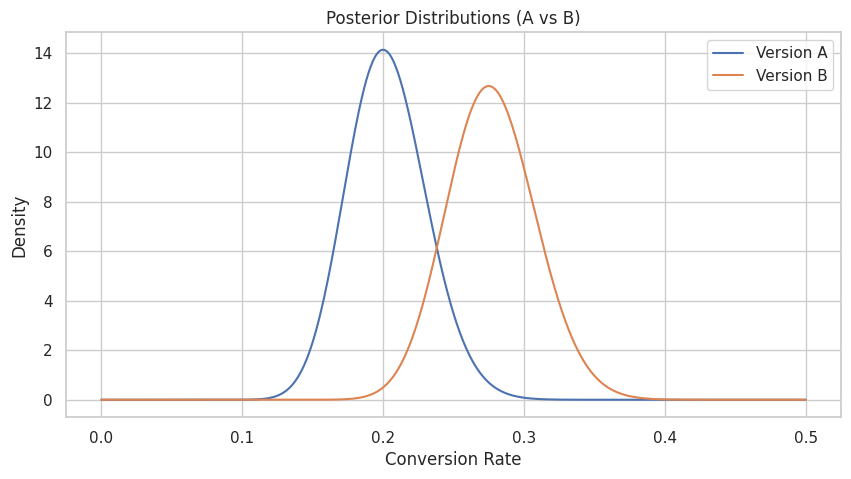

In [ ]:
x = np.linspace(0, 0.5, 1000)

plt.figure(figsize=(10,5))
plt.plot(x, beta.pdf(x, alpha_A, beta_A), label="Version A")
plt.plot(x, beta.pdf(x, alpha_B, beta_B), label="Version B")

plt.title("Posterior Distributions (A vs B)")
plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
samples = 100000

A_samples = np.random.beta(alpha_A, beta_A, samples)
B_samples = np.random.beta(alpha_B, beta_B, samples)

prob = np.mean(B_samples > A_samples)

print("P(B > A):", round(prob, 4))

P(B > A): 0.9586


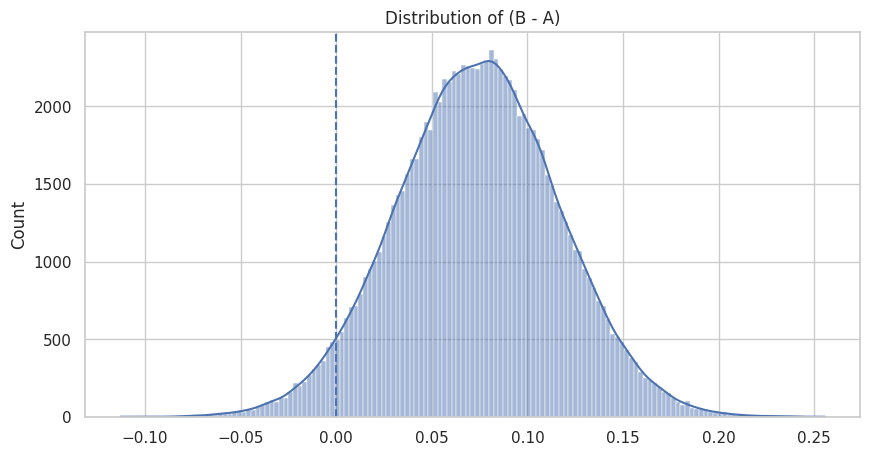

In [ ]:
diff = B_samples - A_samples

plt.figure(figsize=(10,5))
sns.histplot(diff, kde=True)
plt.axvline(0, linestyle='--')

plt.title("Distribution of (B - A)")
plt.show()

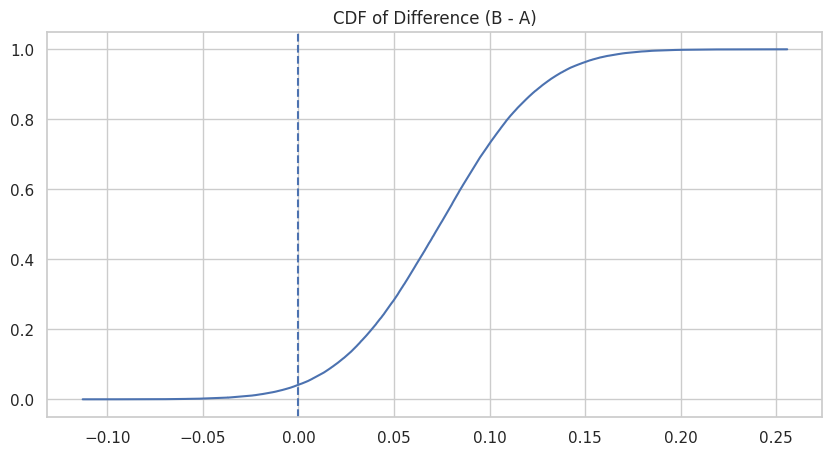

In [ ]:
sorted_diff = np.sort(diff)
cdf = np.arange(len(diff)) / len(diff)

plt.figure(figsize=(10,5))
plt.plot(sorted_diff, cdf)
plt.axvline(0, linestyle='--')

plt.title("CDF of Difference (B - A)")
plt.show()

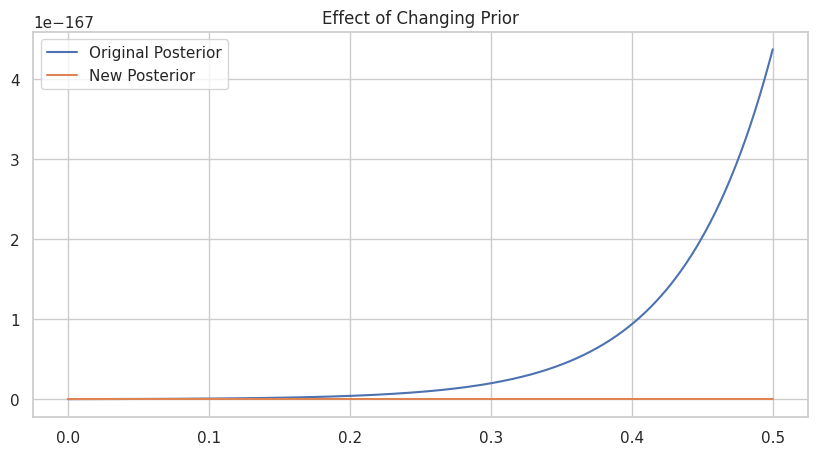

In [ ]:
# Try strong prior
prior_mean_new = 45
prior_sd_new = 5

posterior_var_new = 1 / ((1/prior_sd_new**2) + (n/sigma**2))
posterior_mean_new = posterior_var_new * (
    (prior_mean_new/prior_sd_new**2) + (n*sample_mean/sigma**2)
)

plt.figure(figsize=(10,5))
plt.plot(x, norm.pdf(x, posterior_mean, posterior_sd), label="Original Posterior")
plt.plot(x, norm.pdf(x, posterior_mean_new, np.sqrt(posterior_var_new)), label="New Posterior")

plt.legend()
plt.title("Effect of Changing Prior")
plt.show()

In [ ]:
from scipy.stats import t

# Frequentist 95% Confidence Interval
sample_sd = np.std(data, ddof=1)
se = sample_sd / np.sqrt(n)

t_value = t.ppf(0.975, df=n-1)

ci_lower = sample_mean - t_value * se
ci_upper = sample_mean + t_value * se

print("Frequentist CI:", (round(ci_lower, 3), round(ci_upper, 3)))
print("Bayesian Credible Interval:", (round(lower, 3), round(upper, 3)))

Frequentist CI: (np.float64(46.758), np.float64(53.479))
Bayesian Credible Interval: (np.float64(46.594), np.float64(53.635))


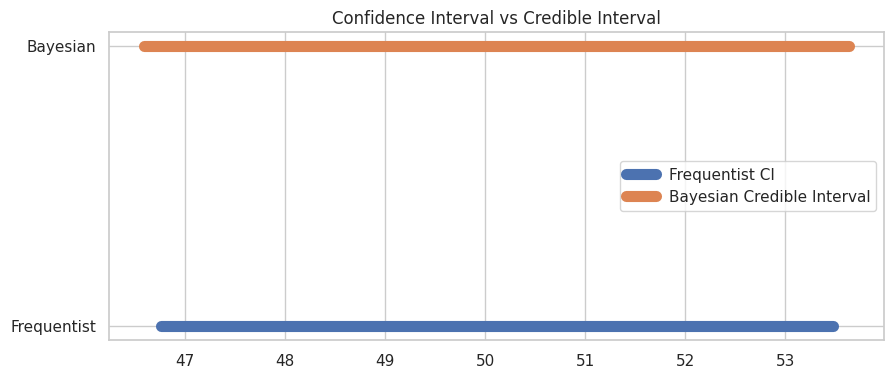

In [ ]:
plt.figure(figsize=(10,4))

# Frequentist CI
plt.plot([ci_lower, ci_upper], [1,1], linewidth=8, label='Frequentist CI')

# Bayesian Credible Interval
plt.plot([lower, upper], [2,2], linewidth=8, label='Bayesian Credible Interval')

plt.yticks([1,2], ['Frequentist', 'Bayesian'])
plt.title("Confidence Interval vs Credible Interval")
plt.legend()
plt.show()

In [ ]:
from scipy.stats import ttest_1samp

t_stat, p_value = ttest_1samp(data, popmean=50)

print("Frequentist p-value:", round(p_value, 5))
print("Bayes Factor:", round(BF10, 5))

Frequentist p-value: 0.94299
Bayes Factor: 1.00211


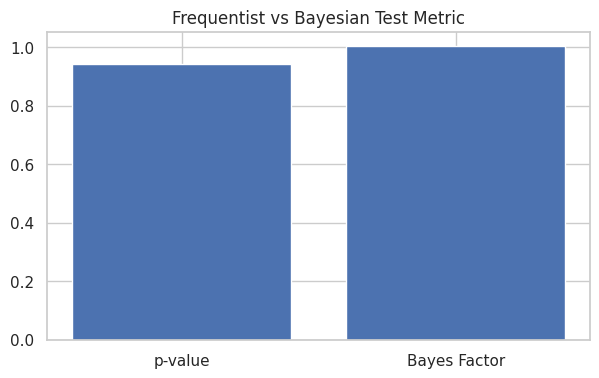

In [ ]:
metrics = ['p-value', 'Bayes Factor']
values = [p_value, BF10]

plt.figure(figsize=(7,4))
bars = plt.bar(metrics, values)

plt.title("Frequentist vs Bayesian Test Metric")
plt.show()

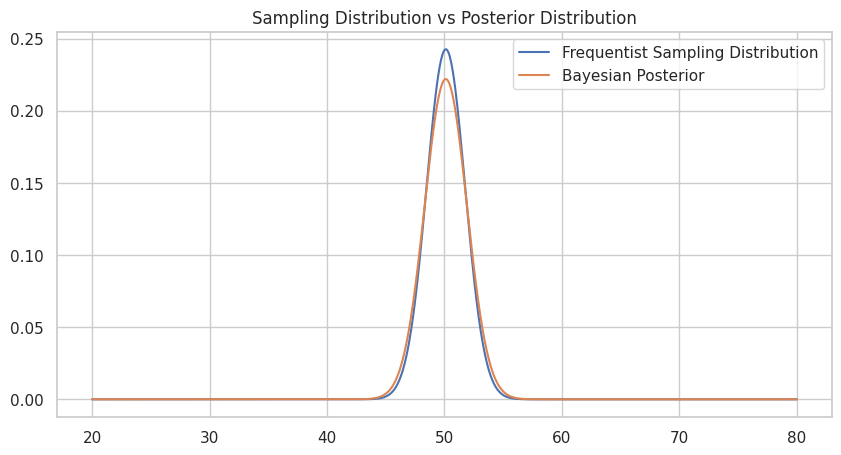

In [ ]:
x = np.linspace(20, 80, 1000)

sampling_dist = norm.pdf(x, sample_mean, se)

plt.figure(figsize=(10,5))
plt.plot(x, sampling_dist, label='Frequentist Sampling Distribution')
plt.plot(x, norm.pdf(x, posterior_mean, posterior_sd), label='Bayesian Posterior')

plt.title("Sampling Distribution vs Posterior Distribution")
plt.legend()
plt.show()

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

successes = [40, 55]
trials = [200, 200]

z_stat, p_ab = proportions_ztest(successes, trials)

print("Frequentist A/B p-value:", round(p_ab, 5))
print("Bayesian P(B > A):", round(prob, 5))

Frequentist A/B p-value: 0.078
Bayesian P(B > A): 0.95858


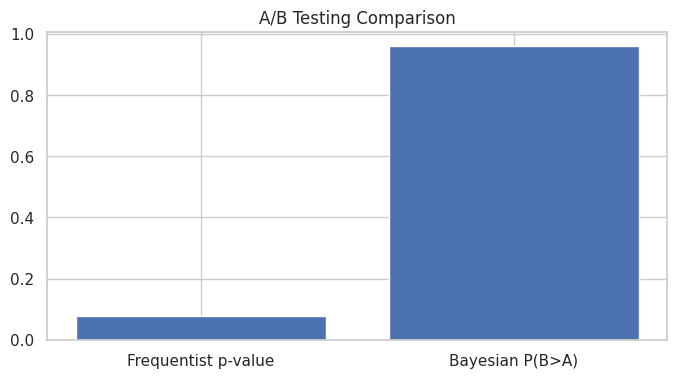

In [ ]:
labels = ['Frequentist p-value', 'Bayesian P(B>A)']
values = [p_ab, prob]

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.title("A/B Testing Comparison")
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Aspect': [
        'Interpretation',
        'Output',
        'Uses Prior?',
        'Hypothesis Result',
        'A/B Test Output'
    ],
    'Frequentist': [
        'Probability of data given H0',
        'p-value / CI',
        'No',
        'Reject / Fail to Reject',
        'p-value'
    ],
    'Bayesian': [
        'Probability of hypothesis given data',
        'Posterior / BF / Credible Interval',
        'Yes',
        'Strength of Evidence',
        'P(B > A)'
    ]
})

comparison

,Aspect,Frequentist,Bayesian
0,Interpretation,Probability of data given H0,Probability of hypothesis given data
1,Output,p-value / CI,Posterior / BF / Credible Interval
2,Uses Prior?,No,Yes
3,Hypothesis Result,Reject / Fail to Reject,Strength of Evidence
4,A/B Test Output,p-value,P(B > A)
